## Spatial RNA + ATAC dataset


In [1]:
import squidpy as sq
import anndata as adata
import mudata as md
import muon as mu
import scanpy as sc
import matplotlib.pyplot as plt
from topomics.models.amortizedLDA import MultimodalAmortizedLDA
import topomics

import warnings
warnings.filterwarnings('ignore', message='.*was not registered in the param store.*')
warnings.filterwarnings('ignore', message='.*Found plate statements in guide but not model.*')

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autono

In [2]:
print(topomics.__file__)

/u/f/fcaretti/topomics/src/topomics/__init__.py


In [3]:
adata_atac = sc.read_h5ad('/data/Data_SpatialGlue/Dataset10_Mouse_Brain_H3K27me3/adata_peaks_normalized.h5ad')
adata_rna = sc.read_h5ad('/data/Data_SpatialGlue/Dataset10_Mouse_Brain_H3K27me3/adata_RNA.h5ad')

In [4]:
import numpy as np
import scipy.sparse as sp

X = adata_atac.X
if sp.issparse(X):
    X = X.tocsr(copy=True)
    X.data = np.ones_like(X.data)
    X.eliminate_zeros()
    adata_atac.layers["binary"] = X
else:
    adata_atac.layers["binary"] = (X != 0).astype(np.float32)


In [5]:
mdata = md.MuData({"rna": adata_rna, "atac": adata_atac})

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [6]:
mdata

MuData object with n_obs × n_vars = 9752 × 96351
  2 modalities
    rna:	9752 x 25881
      obs:	'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'nCount_H3K27me3', 'nFeature_H3K27me3', 'nCount_peaks', 'nFeature_peaks', 'RNA_clusters', 'H3K27me3_clusters'
      var:	'name'
      obsm:	'X_lsi', 'X_pca', 'X_umap', 'spatial'
    atac:	9752 x 70470
      obs:	'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'nCount_H3K27me3', 'nFeature_H3K27me3', 'nCount_peaks', 'nFeature_peaks', 'RNA_clusters', 'H3K27me3_clusters'
      var:	'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'count', 'percentile'
      obsm:	'X_lsi', 'X_pca', 'X_umap', 'spatial'
      layers:	'binary'

In [7]:
import scanpy as sc

# pick modality to source coords from
mod = "rna"  # or "atac"
adata = mdata.mod[mod]

# ensure coords live in .obsm["spatial"]
# (if they are already there, skip this)
# adata.obsm["spatial"] = coords_array  # shape (n_obs, 2)

# build neighbor graph from spatial coordinates
sc.pp.neighbors(
    adata,
    use_rep="spatial",
    n_neighbors=5,
    metric="euclidean",
    key_added="spatial",
)

# store connectivities under a clear key for the model
mdata.obsp["spatial_connectivities"] = adata.obsp["spatial_connectivities"]
adata.obsp["spatial_distances"] = adata.obsp["spatial_distances"]
mdata.mod["atac"].obsp["spatial_connectivities"] = mdata.mod["rna"].obsp["spatial_connectivities"]
mdata.mod["atac"].obsp["spatial_distances"] = mdata.mod["rna"].obsp["spatial_distances"]



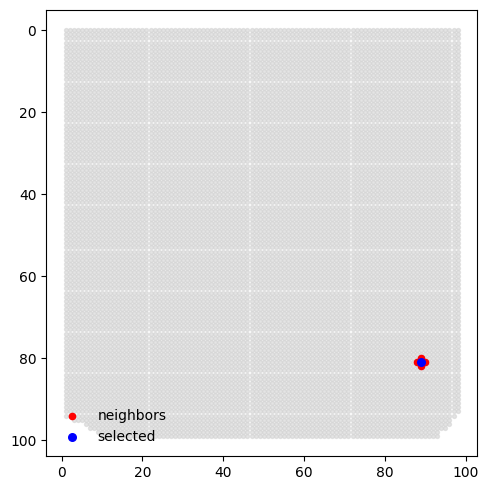

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

coords = adata.obsm["spatial"]
G = adata.obsp["spatial_connectivities"]
if sparse.issparse(G):
    G = G.tocsr()

# pick a point index (e.g., 0 or a random one)
i = 111
neighbors = G[i].indices  # row neighbors

# plot all points in light gray
plt.figure(figsize=(5, 5))
plt.scatter(coords[:, 0], coords[:, 1], s=8, c="lightgray", alpha=0.6)

# plot neighbors in red
plt.scatter(coords[neighbors, 0], coords[neighbors, 1], s=20, c="red", label="neighbors")

# plot the selected point in blue
plt.scatter(coords[i, 0], coords[i, 1], s=30, c="blue", label="selected")

plt.gca().invert_yaxis()  # typical for spatial grids
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [9]:
from topomics.models.amortizedLDA import MultimodalAmortizedLDA

model = MultimodalAmortizedLDA.from_data(
    mdata,
    layers={"rna": None, "atac": 'binary'},  # or None to use .X
    n_topics=10,
    likelihoods=["gamma_poisson", "bernoulli"],
    weight_mode="cell",
    cell_topic_prior=1/10,
    #topic_variance_weight = 10000,
    #entropy_weight=10,
    spatial_keys="spatial_connectivities",
    kl_weight = 1,
    #topic_feature_prior_type='horseshoe'
)

for enc in model.module.guide.gcn_encoders:
    enc.alpha_param.requires_grad_(False)
    enc.alpha=0.2

print(model.module._guide.use_gcn)

True


In [10]:
model.train(
    max_epochs=50,
    batch_size=256,
    plan_kwargs={"optim_kwargs": {"lr": 1e-2}},
)


theta = model.get_cell_topic_dist()  # cell x topic dataframe

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/pyro/primitives.py:163: RuntimeWarning: trying to observe a value outside of inference at topic_variance_bonus
  warnings.warn(


Epoch 50/50: 100%|██████████| 50/50 [04:51<00:00,  5.90s/it, v_num=1, elbo_val=2.23e+7, elbo_train=1.88e+8]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [04:51<00:00,  5.84s/it, v_num=1, elbo_val=2.23e+7, elbo_train=1.88e+8]


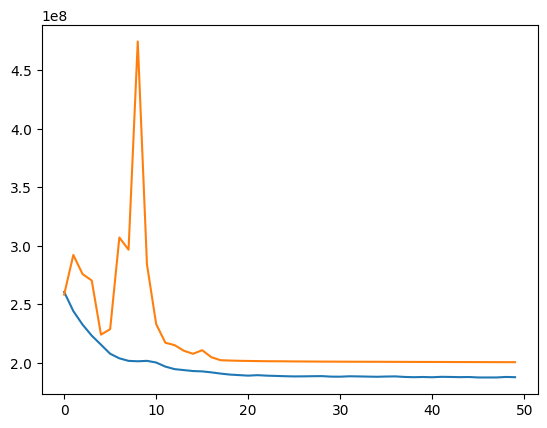

In [11]:
plt.plot(model.history['elbo_train'])
plt.plot(model.history['elbo_val']*9)

In [12]:
import numpy as np
import pandas as pd
import scanpy as sc

# 1) Topic proportions per cell, visualized on UMAP
theta = model.get_latent_representation(batch_size=adata_rna.n_obs)  # full batch
mdata.obsm["X_topic"] = theta.values-1
mdata.obs["top_topic"] = theta.idxmax(axis=1)
mdata['rna'].obsm['X_topic'] = theta.values-1

#sc.pl.umap(adata_rna, color=["top_topic"], frameon=False, s=10)

In [13]:
sc.pp.neighbors(mdata['rna'], metric='cosine', use_rep='X_topic', key_added='topic_neighbors')
sc.tl.umap(mdata['rna'], neighbors_key = 'topic_neighbors', key_added = 'topic_umap')


In [14]:
sc.tl.leiden(mdata['rna'], neighbors_key='topic_neighbors')

/tmp/ipykernel_2630907/2840965842.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(mdata['rna'], neighbors_key='topic_neighbors')


In [15]:
mdata['rna'].obs['leiden']
mdata.obs['leiden']=mdata['rna'].obs['leiden']

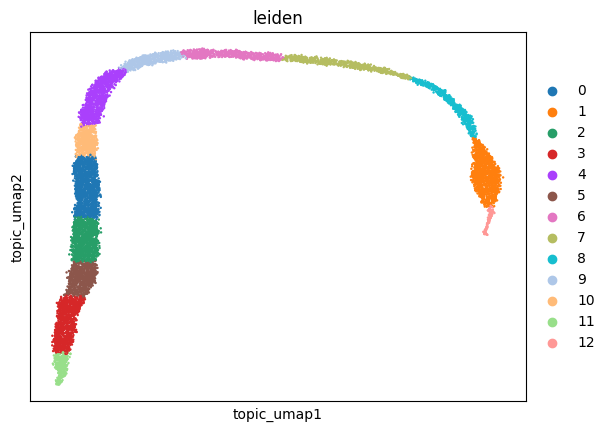

In [16]:
mu.pl.embedding(mdata, basis='rna:topic_umap', color = 'leiden')

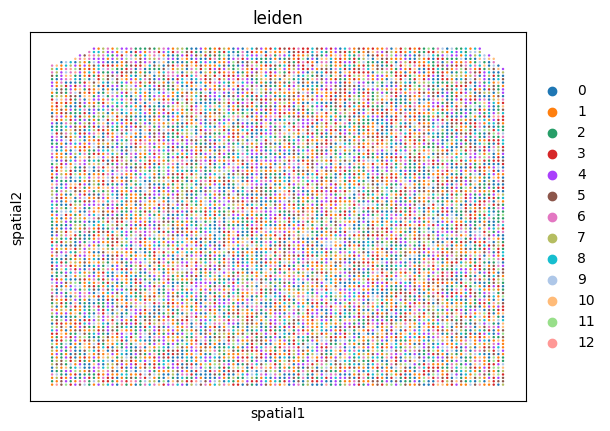

In [17]:
import scanpy as sc

mu.pl.embedding(mdata, basis="rna:spatial", color="leiden")

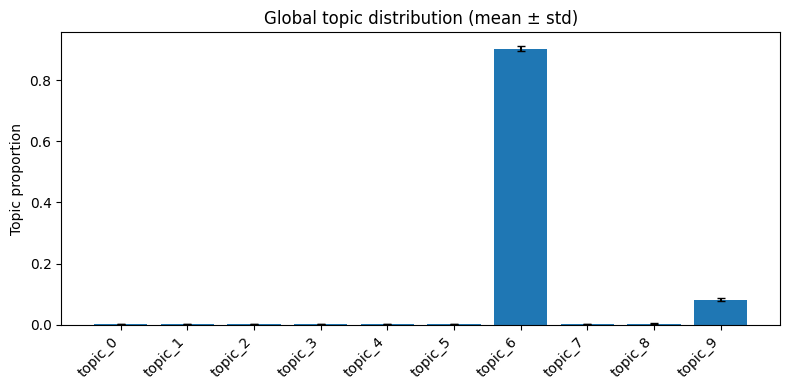

In [18]:
import matplotlib.pyplot as plt
import numpy as np

theta = model.get_latent_representation( batch_size=mdata.n_obs)  # full batch for GCN

means = theta.mean(axis=0)
stds = theta.std(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(means)), means.values, yerr=stds.values, capsize=3)
plt.xticks(np.arange(len(means)), means.index, rotation=45, ha="right")
plt.ylabel("Topic proportion")
plt.title("Global topic distribution (mean ± std)")
plt.tight_layout()
plt.show()

In [ ]:
mdata[mdata['rna'].obs['leiden']=='15']['rna'].obsm['spatial']

ArrayView([], shape=(0, 2), dtype=float32)

: 